In [380]:
import matplotlib.pyplot as plt
import ast
import pandas as pd
import numpy as np
import cnn_surgery.utils.metrics as metrics

In [381]:
DATASET = 'mnist'
file_path = f'./../datar/{DATASET}_class_evaluation_baselines_relative.csv'
df = pd.read_csv(file_path)

In [382]:
df.steps.max()

1999

In [383]:
# filters
df_filtered = df
df_filtered = df[~df['original_accuracy'].apply(lambda x: 0.0 in ast.literal_eval(x))]
df_filtered = df_filtered[~df_filtered.apply(lambda row: ast.literal_eval(row['original_accuracy'])[row['target_class']] < 0.1, axis=1)]
#df_filtered = df_filtered[~df_filtered.apply(lambda row: np.mean(ast.literal_eval(row['original_accuracy'])) < 0.7, axis=1)]
df_filtered = df_filtered[~(df_filtered['distance_travelled'] < 1.0)]
df_filtered = df_filtered[~(df_filtered['steps'] == 1999)]
df = df_filtered

In [384]:
df['target_accuracy_before'] = df.apply(lambda row: ast.literal_eval(row['original_accuracy'])[row['target_class']], axis=1)
df['target_accuracy_after'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after'])[row['target_class']], axis=1)
df['target_accuracy_rv'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after_rv'])[row['target_class']], axis=1)
df['target_accuracy_fa'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after_fa'])[row['target_class']], axis=1)

df['relative_target_accuracy_after'] = df['target_accuracy_after'] / df['target_accuracy_before']
df['relative_target_accuracy_rv'] = df['target_accuracy_rv'] / df['target_accuracy_before']
df['relative_target_accuracy_fa'] = df['target_accuracy_fa'] / df['target_accuracy_before']

df['mean_retain_accuracy_before'] = df.apply(lambda row: np.mean([ast.literal_eval(row['original_accuracy'])[i] for i in range(len(ast.literal_eval(row['original_accuracy']))) if i != row['target_class']]), axis=1)
df['mean_retain_accuracy_after'] = df.apply(lambda row: np.mean([ast.literal_eval(row['accuracy_after'])[i] for i in range(len(ast.literal_eval(row['original_accuracy']))) if i != row['target_class']]), axis=1)
df['mean_retain_accuracy_rv'] = df.apply(lambda row: np.mean([ast.literal_eval(row['accuracy_after_rv'])[i] for i in range(len(ast.literal_eval(row['original_accuracy']))) if i != row['target_class']]), axis=1)
df['mean_retain_accuracy_fa'] = df.apply(lambda row: np.mean([ast.literal_eval(row['accuracy_after_fa'])[i] for i in range(len(ast.literal_eval(row['original_accuracy']))) if i != row['target_class']]), axis=1)

df['relative_mean_retain_accuracy_after'] = df['mean_retain_accuracy_after'] / df['mean_retain_accuracy_before']
df['relative_mean_retain_accuracy_rv'] = df['mean_retain_accuracy_rv'] / df['mean_retain_accuracy_before']
df['relative_mean_retain_accuracy_fa'] = df['mean_retain_accuracy_fa'] / df['mean_retain_accuracy_before']

In [385]:
groups = df.groupby('target_class')
tables = {}
relative = False

if relative:
    relative = 'relative_'
else:
    relative = ''

for group in groups:
    target_class, group_df = group  # Unpack the tuple
    table = pd.DataFrame({
        'before': {
            'target': group_df['target_accuracy_before'].median(),
            'control': group_df['mean_retain_accuracy_before'].median(),
        },
        'Gradient Ascent': {
            'target': group_df[relative + 'target_accuracy_fa'].median(),
            'control': group_df[relative + 'mean_retain_accuracy_fa'].median(),
        },
        'Random Vector': {
            'target': group_df[relative + 'target_accuracy_rv'].median(),
            'control': group_df[relative + 'mean_retain_accuracy_rv'].median(),
        },
        'Our Method': {
            'target': group_df[relative + 'target_accuracy_after'].median(),
            'control': group_df[relative + 'mean_retain_accuracy_after'].median(),
        },
    })
    table.rename(index={'target': f'target ({len(df)})'}, inplace=True)
    tables[target_class] = table

814
70
4711
2922
4160
4350
715
1269
3484
4526


In [386]:
for table in tables:
    print(f'Target Class: {table}')
    print(tables[table].T.round(2))

Target Class: 0
                 target  control
before             0.86     0.77
Gradient Ascent    0.00     0.21
Random Vector      0.77     0.64
Our Method         0.69     0.54
Target Class: 1
                 target  control
before             0.97     0.42
Gradient Ascent    0.00     0.17
Random Vector      0.95     0.36
Our Method         0.63     0.36
Target Class: 2
                 target  control
before             0.85     0.90
Gradient Ascent    0.00     0.13
Random Vector      0.77     0.81
Our Method         0.41     0.69
Target Class: 3
                 target  control
before             0.85     0.85
Gradient Ascent    0.00     0.11
Random Vector      0.83     0.77
Our Method         0.85     0.66
Target Class: 4
                 target  control
before             0.91     0.90
Gradient Ascent    0.00     0.11
Random Vector      0.88     0.86
Our Method         0.74     0.77
Target Class: 5
                 target  control
before             0.86     0.92
Gradient Asce

In [387]:
print(tables[table].T.round(2).to_latex(float_format="%.2f"))

\begin{tabular}{lrr}
\toprule
 & target & control \\
\midrule
before & 0.88 & 0.90 \\
Gradient Ascent & 0.00 & 0.14 \\
Random Vector & 0.82 & 0.84 \\
Our Method & 0.38 & 0.76 \\
\bottomrule
\end{tabular}



In [388]:
print(df.target_accuracy_before.mean())
print(df.mean_retain_accuracy_before.mean())

0.8127960842918471
0.8402405556792092


In [389]:
df['target_over_overall'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after'])[row['target_class']], axis=1) / df['overall_accuracy']
df['target_over_overall_rv'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after_rv'])[row['target_class']], axis=1) / df['overall_accuracy_rv']
df['mean_rest_acc'] = df.apply(lambda row: np.mean([x for i,x in enumerate(ast.literal_eval(row['accuracy_after'])) if i != row['target_class']]), axis=1)
df['mean_rest_acc_rv'] = df.apply(lambda row: np.mean([x for i,x in enumerate(ast.literal_eval(row['accuracy_after_rv'])) if i != row['target_class']]), axis=1)
df['avg_retain_accuracy'] = df.apply(lambda row: metrics.avg_retain_accuracy(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class'], proportional=True), axis=1)
df['avg_retain_accuracy_rv'] = df.apply(lambda row: metrics.avg_retain_accuracy(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class'], proportional=True), axis=1)
# calculate metrics
df['max_difference'] = df.apply(lambda row: metrics.max_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
df['mean_difference'] = df.apply(lambda row: metrics.mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
df['clipped_negative_mean_difference'] = df.apply(lambda row: metrics.clipped_negative_mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
#df['relative_clipped_negative_mean_difference'] = df.apply(lambda row: metrics.clipped_negative_mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class'], proportional=True), axis=1)
df['target_difference'] = df.apply(lambda row: metrics.target_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
df['relative_target_difference'] = df.apply(lambda row: metrics.target_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class'], proportional=True), axis=1)
df['relative_target_difference_rv'] = df.apply(lambda row: metrics.target_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class'], proportional=True), axis=1)
df['target_accuracy'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after'])[row['target_class']], axis=1)
# metrics for rv
df['max_difference_rv'] = df.apply(lambda row: metrics.max_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class']), axis=1)
df['mean_difference_rv'] = df.apply(lambda row: metrics.mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class']), axis=1)
df['clipped_negative_mean_difference_rv'] = df.apply(lambda row: metrics.clipped_negative_mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class']), axis=1)
df['target_difference_rv'] = df.apply(lambda row: metrics.target_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class']), axis=1)
df['target_accuracy_rv'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after_rv'])[row['target_class']], axis=1)

In [390]:
df.target_accuracy.mean()
df.mean_rest_acc.mean()

0.6673288339466872

In [391]:
for col in df.columns:
    if 'fa' in col: print(col)

accuracy_after_fa
overall_accuracy_fa
target_accuracy_fa
relative_target_accuracy_fa
mean_retain_accuracy_fa
relative_mean_retain_accuracy_fa


In [392]:
df

,model_idx,original_accuracy,original_overall_accuracy,accuracy_after,overall_accuracy,target_class,dataset,lr,stop_threshold,l2_penalty,...,mean_difference,clipped_negative_mean_difference,target_difference,relative_target_difference,relative_target_difference_rv,target_accuracy,max_difference_rv,mean_difference_rv,clipped_negative_mean_difference_rv,target_difference_rv
1,1,"[0.92346936, 0.9876652, 0.8895349, 0.93366337,...",0.9058,"[0.014285714285714285, 0.0, 0.0029069767441860...",0.1581,0,mnist,0.1,0.4,0.0,...,0.187385,0.174608,0.909184,0.984530,0.082873,0.014286,-0.096737,-0.007841,-0.012471,0.076531
4,4,"[0.90816325, 0.99030834, 0.751938, 0.8356436, ...",0.8256,"[0.10408163265306122, 0.0, 0.2596899224806202,...",0.2637,0,mnist,0.1,0.4,0.0,...,0.270782,0.254720,0.804082,0.885393,0.247191,0.104082,-0.600145,-0.084822,-0.101576,0.224490
5,5,"[0.93163264, 0.97444934, 0.89437985, 0.9178217...",0.9163,"[0.7377551020408163, 0.8440528634361234, 0.875...",0.7750,0,mnist,0.1,0.4,0.0,...,0.056442,0.052034,0.193878,0.208105,0.048193,0.737755,-0.071834,0.003064,-0.003320,0.044898
8,8,"[0.8642857, 0.96387666, 0.6996124, 0.73069304,...",0.7722,"[0.8571428571428571, 0.9647577092511013, 0.692...",0.6995,0,mnist,0.1,0.4,0.0,...,-0.079172,-0.114244,0.007143,0.008264,-0.018890,0.857143,-0.183333,-0.038679,-0.041570,-0.016327
13,13,"[0.7234694, 0.9603524, 0.39534885, 0.76930696,...",0.5999,"[0.6591836734693878, 0.8343612334801762, 0.038...",0.4763,0,mnist,0.1,0.4,0.0,...,-0.064061,-0.086594,0.064286,0.088858,-0.014104,0.659184,-0.122607,-0.033636,-0.035461,-0.010204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69052,7488,"[0.96836734, 0.9585903, 0.9156977, 0.8990099, ...",0.9183,"[0.9714285714285714, 0.9418502202643172, 0.888...",0.9112,9,mnist,0.1,0.4,0.0,...,0.016095,0.008224,0.021804,0.023404,0.002128,0.909812,-0.021439,-0.001358,-0.004940,0.001982
69053,7489,"[0.8704082, 0.91453743, 0.51937985, 0.7336634,...",0.7473,"[0.8561224489795919, 0.9162995594713657, 0.632...",0.6420,9,mnist,0.1,0.4,0.0,...,0.377617,0.331004,0.451933,0.535211,0.126761,0.392468,-0.050583,0.105360,0.058698,0.107037
69056,7492,"[0.9887755, 0.9929515, 0.96511626, 0.9643564, ...",0.9710,"[0.9948979591836735, 0.9083700440528635, 0.929...",0.9339,9,mnist,0.1,0.4,0.0,...,0.060754,0.055934,0.092170,0.095876,0.016495,0.869177,-0.012170,0.011644,0.009836,0.015857
69057,7493,"[0.96224487, 0.9876652, 0.9118217, 0.9237624, ...",0.9331,"[0.41836734693877553, 0.019383259911894272, 0....",0.2589,9,mnist,0.1,0.4,0.0,...,0.248518,0.246199,0.887017,1.000000,0.218994,0.000000,-0.652999,-0.246887,-0.258413,0.194252


<Axes: ylabel='Frequency'>

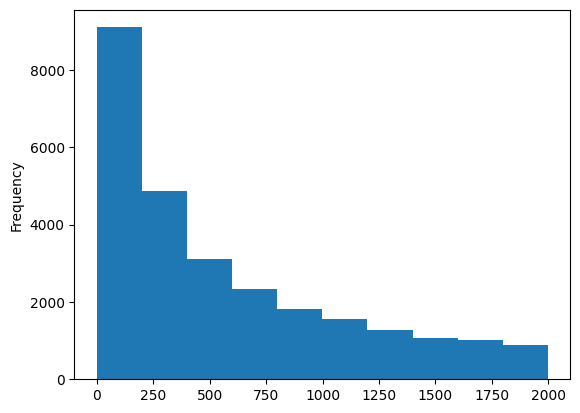

In [393]:
df.steps.plot.hist()